# Tutorial 24: Staggered Rollout or a Simple 2×2? A Power-Analysis Decision Guide

You're running a geo experiment — a feature rolled out across the **50 US states**. The
rollout is *staggered*: a clean pre-period, then states switch on in waves over several
weeks, then a fully-treated tail. A handful of states are held back as a never-treated
control.

The tempting move is to **collapse to a 2×2** — average each state's "before" and "after"
and run one treated-vs-holdout difference-in-differences. It's familiar, and you worry
that a staggered estimator like **Callaway–Sant'Anna (CS)** will *cost you power* and bury
the lift you're trying to detect.

This notebook settles that worry with power analysis. The short version:

1. The collapsed 2×2 doesn't *simplify* the question — it silently answers a **different,
   diluted** one (sometimes reporting a number whose 95% CI never contains the truth).
2. CS **does** cost some detection power — but the cost is *smallest exactly when the
   rollout is staggered enough to need it.*

Everything below runs live on synthetic data (`generate_staggered_data`), so the ground
truth is known and you can re-run it on your own design.

> **See also:** Tutorial&nbsp;06 (power-analysis basics), Tutorial&nbsp;02 (staggered DiD),
> Tutorial&nbsp;18 (geo experiments).

In [1]:
%matplotlib inline
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from diff_diff import generate_staggered_data, CallawaySantAnna, DifferenceInDifferences

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams["figure.figsize"] = (9, 5)

# ---- our geo design: 50 states, 24 weeks, ~10 held back as control ----
N_STATES, N_WEEKS, HOLDOUT, GROWTH, NOISE = 50, 24, 0.20, 0.05, 1.0
ROLLOUTS = {"fast": (8, 9, 10), "moderate": (8, 10, 12, 14), "slow": (8, 12, 16, 20)}


def make_panel(cohorts, effect, seed, n_states=N_STATES, growth=GROWTH):
    '''A staggered geo panel. `effect` is the per-state lift once a state is live
    (baseline outcome is ~10, so effect=0.5 is roughly a 5% lift).'''
    return generate_staggered_data(
        n_units=n_states, n_periods=N_WEEKS, cohort_periods=list(cohorts),
        never_treated_frac=HOLDOUT, treatment_effect=effect, dynamic_effects=True,
        effect_growth=growth, unit_fe_sd=2.0, time_trend=0.1, noise_sd=NOISE,
        seed=seed, panel=True)


def collapse_2x2(panel, rollout_start, tail_start=None):
    '''Collapse to a literal 2x2 (one pre + one post cell per state). If `tail_start`
    is given, use only the clean all-treated tail as 'post' and drop the rollout window.'''
    d = panel.copy()
    if tail_start is None:
        d["post"] = (d["period"] >= rollout_start).astype(int)
    else:
        d = d[(d["period"] < rollout_start) | (d["period"] >= tail_start)].copy()
        d["post"] = (d["period"] >= tail_start).astype(int)
    return d.groupby(["unit", "post"], as_index=False).agg(
        outcome=("outcome", "mean"), treated=("treat", "max"))


def fit_2x2(panel, rollout_start, tail_start=None):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r = DifferenceInDifferences(cluster="unit").fit(
            collapse_2x2(panel, rollout_start, tail_start),
            outcome="outcome", treatment="treated", time="post")
    return r.att, r.se, r.conf_int, bool(r.p_value < 0.05)


def fit_cs(panel):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        r = CallawaySantAnna(control_group="never_treated").fit(
            panel, outcome="outcome", unit="unit", time="period", first_treat="first_treat")
    return r.overall_att, r.overall_se, r.overall_conf_int, bool(r.overall_p_value < 0.05)


def estimands(panel, rollout_start):
    '''The two estimands, read off the noise-free `true_effect` column.
    E1 = effect while a state is actually treated (CS's target);
    E2 = E1 diluted by not-yet-live states counted as 'post' (the 2x2's target).'''
    on = panel["treated"] == 1
    E1 = float(panel.loc[on, "true_effect"].mean())
    grp = panel[panel["treat"] == 1]
    post = grp["period"] >= rollout_start
    E2 = float(grp.loc[post, "true_effect"].mean())
    return E1, E2

## The scenario

Think of a **24-week** test: an **8-week clean pre-period** (no state treated yet), then a
**16-week post window** over which states go live in waves and then stay live. **40 of the 50
states** get the feature; the other **10 are never treated** (the control group). Effects
**grow** a little each week after a state goes live (a realistic ramp).

Everything turns on *how spread out the adoption waves are*. So we compare three rollout
**speeds** — same 24 weeks, same 40 / 10 split, **only the wave timing changes**:

Same 24-week test (8-week clean pre + 16-week post) and 40 treated / 10 held back each time.
Only the wave timing changes:



,rollout,waves go live (week),wave spacing,all states live by week,weeks fully live (of 16 post),avg % of states live across post
0,fast,"[8, 9, 10]",~weekly,10,14,94
1,moderate,"[8, 10, 12, 14]",every 2 weeks,14,10,80
2,slow,"[8, 12, 16, 20]",every 4 weeks,20,4,61


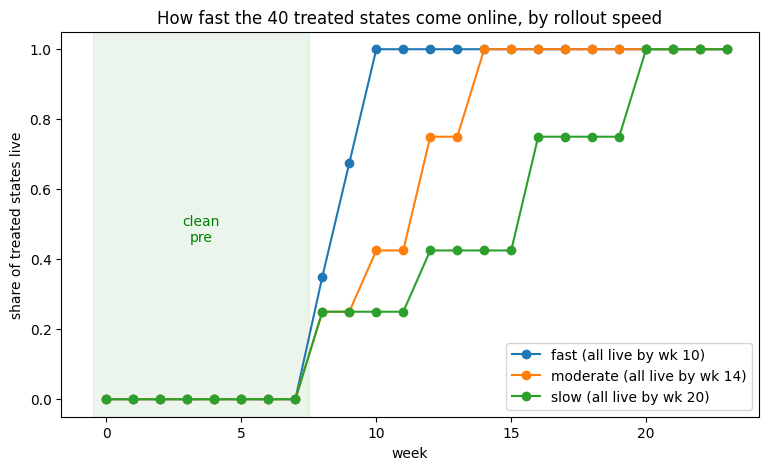

In [2]:
# our running example uses the MODERATE rollout
panel = make_panel(ROLLOUTS["moderate"], effect=2.0, seed=0)
rollout_start = min(ROLLOUTS["moderate"])   # week 8 for all three speeds

def calendar(name, cohorts):
    p = make_panel(cohorts, effect=1.0, seed=0)
    post = p[(p.treat == 1) & (p.period >= min(cohorts))]
    avg_live = post.groupby("period")["treated"].mean().mean()
    spacing = {"fast": "~weekly", "moderate": "every 2 weeks", "slow": "every 4 weeks"}[name]
    return {"rollout": name, "waves go live (week)": str(list(cohorts)), "wave spacing": spacing,
            "all states live by week": max(cohorts),
            "weeks fully live (of 16 post)": N_WEEKS - max(cohorts),
            "avg % of states live across post": round(100 * avg_live)}

cal = pd.DataFrame([calendar(n, c) for n, c in ROLLOUTS.items()])
print("Same 24-week test (8-week clean pre + 16-week post) and 40 treated / 10 held back each time.")
print("Only the wave timing changes:\n")
display(cal)

# How fast the 40 treated states come online, by speed
plt.figure(figsize=(9, 5))
for name, coh in ROLLOUTS.items():
    s = make_panel(coh, 1.0, 0)
    s = s[s.treat == 1].groupby("period")["treated"].mean()
    plt.plot(s.index, s.values, marker="o", label=f"{name} (all live by wk {max(coh)})")
plt.axvspan(-0.5, rollout_start - 0.5, alpha=0.08, color="green")
plt.text((rollout_start - 1) / 2, 0.45, "clean\npre", ha="center", color="green")
plt.title("How fast the 40 treated states come online, by rollout speed")
plt.xlabel("week"); plt.ylabel("share of treated states live")
plt.ylim(-0.05, 1.05); plt.legend(); plt.show()

## "Simplifying" silently changes the question

When you collapse the whole post-window into one "after" cell, the states that *haven't
gone live yet* are still counted as treated. Their flat, pre-treatment outcomes get
averaged into the treated group's "after" mean, **diluting** the estimate.

So the collapsed 2×2 and CS aren't a precise-vs-imprecise pair — they target **different
estimands**: CS's overall ATT targets **E1** (the effect on a state while it's actually live),
the 2×2 targets **E2** (E1 diluted by the not-yet-live states). With effects that grow after
launch, `E2 < E1`. (CS's `overall_att` is the group-size-weighted average of its per-cohort,
per-period ATT(g,t) cells; in this *balanced, absorbing-treatment* design that coincides with
the simple treated-observation mean we call E1 — the ~95% coverage of E1 below bears this out.)
Here is the gap on one panel (large effect so it's visible above noise):

In [3]:
E1, E2 = estimands(panel, rollout_start)
a2, s2, ci2, _ = fit_2x2(panel, rollout_start)
ac, sc, cic, _ = fit_cs(panel)

print(f"True effect-on-treated   (E1): {E1:.2f}")
print(f"Collapsed-2x2 target     (E2): {E2:.2f}   <- diluted by not-yet-live states\n")
print(f"Collapsed 2x2 estimate : {a2:.2f}   95% CI [{ci2[0]:.2f}, {ci2[1]:.2f}]")
print(f"Callaway-Sant'Anna     : {ac:.2f}   95% CI [{cic[0]:.2f}, {cic[1]:.2f}]")
print(f"\nThe 2x2 reports ~{100*a2/ac:.0f}% of CS's number. That gap is not noise — both")
print("estimators are ~unbiased for their OWN target; they just target different things.")

True effect-on-treated   (E1): 2.61
Collapsed-2x2 target     (E2): 2.10   <- diluted by not-yet-live states

Collapsed 2x2 estimate : 2.17   95% CI [1.88, 2.46]
Callaway-Sant'Anna     : 2.67   95% CI [2.26, 3.09]

The 2x2 reports ~81% of CS's number. That gap is not noise — both
estimators are ~unbiased for their OWN target; they just target different things.


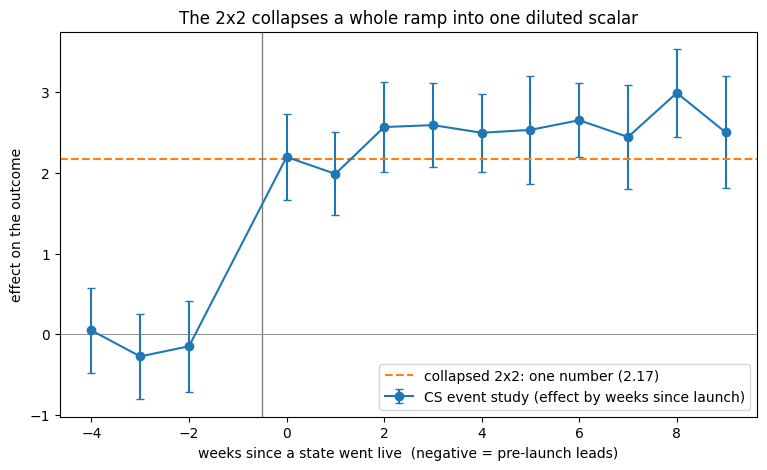

In [4]:
# CS event study with a FIXED pre-launch baseline (base_period="universal"): negative
# periods are proper lead coefficients (a parallel-trends check), positive periods are
# exposure-time effects. (The default "varying" base makes negative periods consecutive
# placebo contrasts instead — see the CallawaySantAnna docs.)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    es = CallawaySantAnna(control_group="never_treated", base_period="universal").fit(
        panel, outcome="outcome", unit="unit", time="period",
        first_treat="first_treat", aggregate="event_study").event_study_effects
ev = np.array(sorted(k for k in es if -4 <= k <= 9))
eff = np.array([es[k]["effect"] for k in ev])
serr = np.array([es[k]["se"] for k in ev])
ok = np.isfinite(serr) & (serr > 0)          # drop the pinned reference period

plt.errorbar(ev[ok], eff[ok], yerr=1.96 * serr[ok], marker="o", capsize=3,
             label="CS event study (effect by weeks since launch)")
plt.axhline(a2, color="C1", ls="--", label=f"collapsed 2x2: one number ({a2:.2f})")
plt.axvline(-0.5, color="gray", lw=1); plt.axhline(0, color="gray", lw=0.6)
plt.title("The 2x2 collapses a whole ramp into one diluted scalar")
plt.xlabel("weeks since a state went live  (negative = pre-launch leads)")
plt.ylabel("effect on the outcome"); plt.legend(); plt.show()

The slower the rollout, the more dilution. Let's sweep rollout speed and, across many
panels, measure what the 2×2 reports as a share of the truth and how often each method's
95% CI actually contains the true effect-on-treated:

In [5]:
def dilution_row(name, cohorts, n_sims=250):
    rs = min(cohorts)
    # E1/E2 averaged over a few panels = the design's structural estimands (for display)
    E1s, E2s = zip(*[estimands(make_panel(cohorts, 2.0, 900 + s), rs) for s in range(5)])
    E1, E2 = np.mean(E1s), np.mean(E2s)
    cov2, covc = [], []
    for i in range(n_sims):
        p = make_panel(cohorts, 2.0, 1000 + i)
        e1_i = estimands(p, rs)[0]   # this panel's OWN truth (cohort mix is redrawn each panel)
        _, _, c2, _ = fit_2x2(p, rs); cov2.append(c2[0] <= e1_i <= c2[1])
        _, _, cc, _ = fit_cs(p); covc.append(cc[0] <= e1_i <= cc[1])
    return {"rollout": name, "true effect (E1)": E1, "2x2 target (E2)": E2,
            "2x2 reports (% of truth)": 100 * E2 / E1,
            "2x2 CI covers truth": np.mean(cov2), "CS CI covers truth": np.mean(covc)}

dilution = pd.DataFrame([dilution_row(n, c) for n, c in ROLLOUTS.items()])
dilution

,rollout,true effect (E1),2x2 target (E2),2x2 reports (% of truth),2x2 CI covers truth,CS CI covers truth
0,fast,2.700,2.525,93.500,0.796,0.924
1,moderate,2.618,2.117,80.876,0.184,0.960
2,slow,2.554,1.577,61.754,0.004,0.928


Why does the slow rollout dilute so much? The 2×2 averages over **all 16 post-weeks**, but
under a slow rollout the states are all live for only the **last 4 of those 16 weeks** (waves
land a month apart, finishing in week 20) — the other 12 weeks still have states dark. (Notice
the "avg % of states live across post" column from the scenario calendar — 94% / 80% / 61% —
is essentially the "2×2 reports % of truth" above; that *is* the dilution.) So the collapsed
2×2 reports only ~60% of the true lift, and its 95% CI contains the true effect-on-treated
**almost never**. It's not that you can't *detect* an effect — the number you detect is the
wrong number. CS's interval covers the truth ~95% of the time regardless of speed.

## So does CS cost you power? (the headline)

Yes — for *pure detection* the collapsed 2×2 is more powerful, because pooling the whole
post-window into one cell gives it a tighter standard error than CS's group-time-then-
aggregate machinery. The fear is real **in magnitude**. But watch what happens to the MDE —
the smallest lift your 50 states can detect — *as the rollout gets more and more staggered.*

First, the method in miniature — a small paired power estimate (both estimators on the
*same* panels) you can run on your own design:

In [6]:
def paired_power(cohorts, lift, n_sims=250, n_states=N_STATES, seed0=2000):
    '''Fraction of paired panels where each estimator rejects H0: no effect.'''
    rs = min(cohorts)
    rej2, rejc = [], []
    for i in range(n_sims):
        p = make_panel(cohorts, lift, seed0 + i, n_states=n_states)
        rej2.append(fit_2x2(p, rs)[3])
        rejc.append(fit_cs(p)[3])
    return np.mean(rej2), np.mean(rejc)

p2, pc = paired_power(ROLLOUTS["moderate"], lift=0.5)
print(f"True lift 0.5 (~5%), 50 states, moderate rollout:  2x2 power = {p2:.2f}   CS power = {pc:.2f}")

True lift 0.5 (~5%), 50 states, moderate rollout:  2x2 power = 0.90   CS power = 0.75


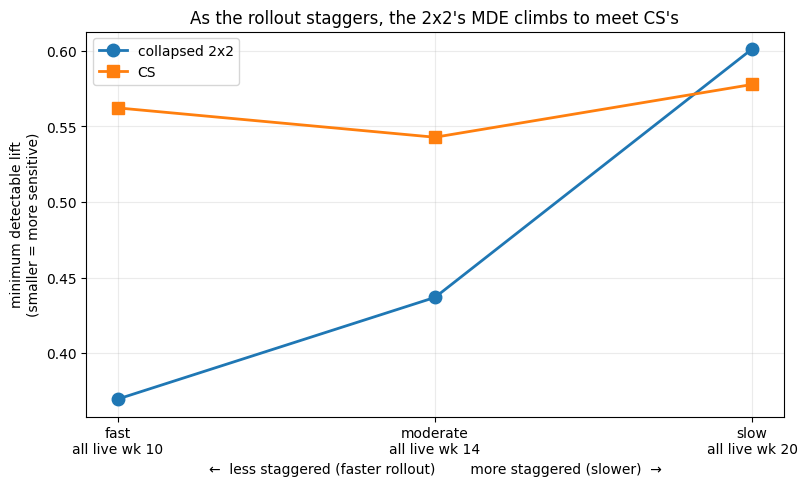

,rollout,all live by wk,2x2 reports (% of truth),MDE 2x2,MDE CS,CS / 2x2 MDE
0,fast,10,93.500,0.370,0.562,1.521
1,moderate,14,80.876,0.437,0.543,1.243
2,slow,20,61.754,0.601,0.578,0.961


In [7]:
# Minimum detectable lift (MDE) as the rollout gets more and more staggered
LIFTS = [0.20, 0.30, 0.40, 0.50, 0.65, 0.85]

def mde(lifts, powers, target=0.80):
    x, y = np.asarray(lifts, float), np.asarray(powers, float)
    if (y >= target).all(): return float(x[0])
    if (y < target).all():  return float("nan")
    i = int(np.argmax(y >= target))
    t = (target - y[i - 1]) / (y[i] - y[i - 1])
    return float(x[i - 1] + t * (x[i] - x[i - 1]))

order = ["fast", "moderate", "slow"]   # increasing stagger -->
rows, mde2, mdec = [], [], []
for name in order:
    coh = ROLLOUTS[name]; rs = min(coh)
    E1, E2 = np.mean([estimands(make_panel(coh, 2.0, 900 + s), rs) for s in range(5)], axis=0)
    pw = np.array([paired_power(coh, L) for L in LIFTS])   # columns: 2x2, CS
    m2, mc = mde(LIFTS, pw[:, 0]), mde(LIFTS, pw[:, 1])
    mde2.append(m2); mdec.append(mc)
    rows.append({"rollout": name, "all live by wk": max(coh),
                 "2x2 reports (% of truth)": 100 * E2 / E1,
                 "MDE 2x2": m2, "MDE CS": mc, "CS / 2x2 MDE": mc / m2})

xx = np.arange(len(order))
plt.plot(xx, mde2, "o-", lw=2, ms=9, label="collapsed 2x2")
plt.plot(xx, mdec, "s-", lw=2, ms=9, label="CS")
plt.xticks(xx, [f"{o}\nall live wk {max(ROLLOUTS[o])}" for o in order])
plt.xlabel("←  less staggered (faster rollout)        more staggered (slower)  →")
plt.ylabel("minimum detectable lift\n(smaller = more sensitive)")
plt.title("As the rollout staggers, the 2x2's MDE climbs to meet CS's")
plt.legend(); plt.grid(alpha=0.25); plt.show()

pd.DataFrame(rows)

There's the answer to "how does the MDE change as the rollout gets more staggered?" Reading
left (a **fast** rollout — all 40 states live within ~2 weeks, week 10) to right (a **slow**
rollout — waves a month apart, everyone live only for the final 4 weeks, by week 20):

- The **2×2's MDE climbs** (~0.37 → ~0.60): the more spread-out the waves, the more the
  dilution eats its signal, so it needs a *bigger* true lift to detect anything.
- **CS's MDE barely moves** (~0.55): it targets the undiluted effect, so its sensitivity
  doesn't degrade as the rollout stretches out.
- So the gap **closes to near parity**: the 2×2 wins on MDE for a near-simultaneous launch,
  but by a month-apart rollout the two are essentially tied (in this design CS's MDE even edges
  slightly ahead — though that exact reversal is simulation-sensitive, so read it as parity) —
  and *there* CS is also unbiased while the 2×2 is reporting only ~60% of the truth.

The fear "CS will cost me power" is really a **fast-rollout** phenomenon. The more drawn-out
your rollout — i.e., the more you actually need a staggered estimator — the more that power
gap shrinks toward parity.

There are only 50 states; you can't go buy more. So the design question isn't "how big a
sample do I need?" — it's "what's the smallest lift my 50 states can detect, and with which
estimator?" A slightly larger MDE that lands on the *right* quantity beats a smaller one that
lands on a diluted one.

## A couple of refinements

**When can a 2×2 ever be unbiased?** Under the assumptions this whole tutorial relies on —
parallel trends vs. the never-treated control, no anticipation, and absorbing treatment — a
2×2 lands on the effect-on-treated only if you (a) use *just* the clean all-treated tail (drop
the rollout window) **and** (b) effects don't change with time-since-launch. When effects are
flat, that clean-tail 2×2 targets the same estimand as CS — and because it pools the whole
tail into one tight pre/post contrast, it's also *more powerful*. When effects **grow**, no
2×2 recovers the effect-on-treated — the naive one reads low, the clean-tail one reads high
(it captures the grown tail). The next two cells show both: first the estimand targeting, then
the flat-effects power comparison.

In [8]:
tail_start = max(ROLLOUTS["moderate"])
for label, growth in [("flat effects", 0.0), ("growing effects", 0.05)]:
    E1s, naive, tail, cs = [], [], [], []
    for s in range(30):                      # average over panels so the centers read cleanly
        p = make_panel(ROLLOUTS["moderate"], effect=2.0, seed=300 + s, growth=growth)
        E1s.append(estimands(p, rollout_start)[0])
        naive.append(fit_2x2(p, rollout_start)[0])
        tail.append(fit_2x2(p, rollout_start, tail_start=tail_start)[0])
        cs.append(fit_cs(p)[0])
    print(f"{label:16s}  true E1={np.mean(E1s):5.2f} | naive-2x2={np.mean(naive):5.2f}  "
          f"clean-tail-2x2={np.mean(tail):5.2f}  CS={np.mean(cs):5.2f}   (mean over 30 panels)")
print("\nFlat: the clean-tail 2x2 lands on the truth (CS agrees — it's then just a diagnostic).")
print("Growing: only CS tracks E1; the clean-tail 2x2 overshoots (it captures the grown tail).")

flat effects      true E1= 2.00 | naive-2x2= 1.62  clean-tail-2x2= 1.98  CS= 1.99   (mean over 30 panels)


growing effects   true E1= 2.62 | naive-2x2= 2.12  clean-tail-2x2= 2.73  CS= 2.60   (mean over 30 panels)

Flat: the clean-tail 2x2 lands on the truth (CS agrees — it's then just a diagnostic).
Growing: only CS tracks E1; the clean-tail 2x2 overshoots (it captures the grown tail).


In [9]:
# ...and it's not just unbiased: under FLAT effects with a clean tail, the clean-tail 2x2
# also detects a smaller lift than CS (it pools the whole tail into one tight contrast).
def paired_power_tail(cohorts, lift, n_sims=250, seed0=4000):
    rs, ts = min(cohorts), max(cohorts)          # clean tail starts after the last wave
    rej_tail, rej_cs = [], []
    for i in range(n_sims):
        p = make_panel(cohorts, lift, seed0 + i, growth=0.0)        # flat effects
        rej_tail.append(fit_2x2(p, rs, tail_start=ts)[3])           # clean-tail 2x2
        rej_cs.append(fit_cs(p)[3])
    return np.mean(rej_tail), np.mean(rej_cs)

pw_flat = np.array([paired_power_tail(ROLLOUTS["moderate"], L) for L in LIFTS])
print("Flat effects, clean all-treated tail, moderate rollout, 50 states:")
for L, (pt, pc) in zip(LIFTS, pw_flat):
    print(f"  lift {L:.2f} (~{L * 10:.0f}%):  clean-tail 2x2 power {pt:.2f}   CS power {pc:.2f}")
print(f"\n  MDE clean-tail 2x2 = {mde(LIFTS, pw_flat[:, 0]):.2f}   vs   MDE CS = {mde(LIFTS, pw_flat[:, 1]):.2f}")
print("  -> same flat-effects estimand, but the clean-tail 2x2 is the more powerful of the two.")

Flat effects, clean all-treated tail, moderate rollout, 50 states:
  lift 0.20 (~2%):  clean-tail 2x2 power 0.25   CS power 0.15
  lift 0.30 (~3%):  clean-tail 2x2 power 0.41   CS power 0.21
  lift 0.40 (~4%):  clean-tail 2x2 power 0.61   CS power 0.37
  lift 0.50 (~5%):  clean-tail 2x2 power 0.78   CS power 0.54
  lift 0.65 (~6%):  clean-tail 2x2 power 0.95   CS power 0.71
  lift 0.85 (~8%):  clean-tail 2x2 power 1.00   CS power 0.94

  MDE clean-tail 2x2 = 0.52   vs   MDE CS = 0.73
  -> same flat-effects estimand, but the clean-tail 2x2 is the more powerful of the two.


**Holdout size.** Geo experiments usually hold back only a few states. We hold this fixed at
10 and don't vary it. One mechanism to keep in mind if you do vary it on your own design: a
small control group inflates the *2×2's* standard error too — not only CS's — so a smaller
holdout won't necessarily widen the CS-vs-2×2 power gap. This notebook doesn't measure that,
so treat it as a hypothesis to test, not a result.

**A 50-state caveat: few clusters.** Our 2×2 helper already clusters by state
(`cluster="unit"`), and with ~50 states (only ~10 controls) cluster-robust SEs lean on
large-sample approximations that are shaky at this scale. For a real 50-state test, prefer
wild-cluster bootstrap or small-sample corrections: `DifferenceInDifferences` supports
`inference="wild_bootstrap"` (it resamples at the cluster level), and `CallawaySantAnna`
supports a multiplier bootstrap via `n_bootstrap=`. See the estimator docstrings for the
exact requirements.

## Decision guide

| Your situation | Use | Why |
|---|---|---|
| Fast rollout, only need "did it work + rough size" | collapsed 2×2 | cheapest power, dilution mild; check CS as a sanity pass |
| Effects are flat **and** you have a clean all-treated tail | clean-tail 2×2 | unbiased *and* more powerful than CS (it pools the tail — shown above); CS = diagnostic |
| Slow / spread-out rollout | **CS** | the 2×2's power edge shrinks and its dilution is worst; honest coverage |
| Effects grow, or you need the magnitude / ROI / dynamics | **CS** | only estimator targeting the effect-on-treated; the event study is the deliverable |

**Bottom line.** "CS will kill my power" is true in magnitude but mis-aimed. CS does cost
power versus the 2×2 — but the cost is smallest exactly where the rollout is staggered enough
to need it, and the 2×2's apparent power is bought by quietly estimating a smaller, diluted
number. The real decision isn't *power vs. no power* — it's *which estimand you actually
want, and whether 50 states can detect it.*

## Run this on your own design

Everything above is reproducible with the public API:

- `generate_staggered_data(...)` builds the panel; tune `cohort_periods` (rollout speed),
  `never_treated_frac` (holdout), `effect_growth` (dynamics), `noise_sd`, `n_units`.
- For a single estimator, `diff_diff.simulate_mde` / `simulate_power` / `simulate_sample_size`
  give MDE, power, and required-N directly (see Tutorial 06).
- For a **fair head-to-head**, compare estimators on the *same* simulated panels (the
  `paired_power` helper above) — the library's `simulate_*` helpers draw independently per
  estimator, which is fine for one estimator but not for a like-for-like contrast.

> **Caveat.** In these sweeps "slower rollout" also leaves a shorter all-treated tail, so
> rollout-spread and tail-length move together; disentangling them is a useful follow-up.

**References:** Callaway & Sant'Anna (2021), *Difference-in-Differences with multiple time
periods*; Roth (2022), *Pre-test with caution*. See `docs/references.rst`.